In [104]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from PIL import Image
from skimage import measure

In [105]:
aperture_shape = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\Demo\\Gigi\\Assets\\NoiseTextures\\UniformStar\\UniformStar.png"

In [106]:
aperture_texture = None
aperture_texture_shape = None
APERTURE_OPEN_THRESHOLD = 0.5
APERTURE_TEXTURE_RADIUS_MM = None
TEXTURED_APERTURE_INDICES = set()

def load_aperture_texture():
    global aperture_texture, aperture_texture_shape
    if aperture_texture is None:
        image = Image.open(aperture_shape).convert("L")
        aperture_texture = np.asarray(image, dtype=np.float32) / 255.0
        aperture_texture_shape = aperture_texture.shape
    return aperture_texture, aperture_texture_shape

In [107]:
N_AIR = 1.0
scale = 0.58

curv = scale * np.array([83.6, 321.0, 44.8, -1150.0, 28.3, -38.5, 50.5, -53.2, 106.0, -120.0])
thick = scale * np.array([10.75, 15.55, 5.05, 5.05, 21.22, 13.9])
gaps = scale * np.array([1.65, 18.9, 0.97])
n_glass = [1.64238, 1.62306, 1.57566, 1.6727, 1.64238, 1.64238]

ratio = (thick.sum() + gaps.sum()) / 40.0
APERTURE_F_STOPS = np.array([2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0])
APERTURE_DIAMETERS_MM = np.array([3.0, 8.0, 12.0, 15.0, 17.2, 19.0, 20.0])
APERTURE_INDEX = len(APERTURE_DIAMETERS_MM) - 1  # widest setting for fully open aperture
APERTURE_RADIUS = 0.5 * APERTURE_DIAMETERS_MM[APERTURE_INDEX] * ratio

radii = 0.5 * np.array([41.5, 30.0, 20.0, 19.0, 25.0]) * ratio
LENS = list(zip(
    [curv[0], curv[1], curv[2], curv[3], curv[4], 0.0, curv[5], curv[6], curv[7], curv[8], curv[9]],
    [thick[0], gaps[0], thick[1], thick[2], gaps[1] * 0.5, gaps[1] * 0.5, thick[3], thick[4], gaps[2], thick[5], 0.0],
    [n_glass[0], N_AIR, n_glass[1], n_glass[2], N_AIR, N_AIR, n_glass[3], n_glass[4], N_AIR, n_glass[5], N_AIR],
    [radii[1], radii[1], radii[1], radii[1], radii[2], APERTURE_RADIUS, radii[3], radii[4], radii[4], radii[4], radii[4]]
) )
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)
TEXTURED_APERTURE_INDICES = {
    idx
    for idx, (curvature, _, _, aperture) in enumerate(LENS)
    if abs(curvature) < 1e-9 and abs(aperture - APERTURE_RADIUS) < 1e-6
}
APERTURE_CHECK_ENABLED = [True] * len(LENS)

def set_aperture_check(element_index, enabled):
    APERTURE_CHECK_ENABLED[element_index] = bool(enabled)

def toggle_aperture_check(element_index):
    APERTURE_CHECK_ENABLED[element_index] = not APERTURE_CHECK_ENABLED[element_index]
    return APERTURE_CHECK_ENABLED[element_index]

def aperture_allows(hit_point, aperture_radius, element_index=None):
    if aperture_radius <= 0.0:
        return True
    x, y = hit_point[0], hit_point[1]
    if element_index is not None and not APERTURE_CHECK_ENABLED[element_index]:
        return True
    if x * x + y * y > aperture_radius * aperture_radius:
        return False
    # Only elements flagged in TEXTURED_APERTURE_INDICES use the texture mask.
    if element_index is None or element_index not in TEXTURED_APERTURE_INDICES:
        return True
    texture, shape = load_aperture_texture()
    if texture is None or shape is None:
        return False
    height, width = shape
    u = 0.5 + 0.5 * (x / aperture_radius)
    v = 0.5 - 0.5 * (y / aperture_radius)
    if u < 0.0 or u > 1.0 or v < 0.0 or v > 1.0:
        return False
    x_idx = int(round(u * (width - 1)))
    y_idx = int(round(v * (height - 1)))
    return texture[y_idx, x_idx] <= APERTURE_OPEN_THRESHOLD

def refract(direction, normal, eta):
    cos_i = -np.dot(normal, direction)
    sin2_t = eta * eta * (1.0 - cos_i * cos_i)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(max(0.0, 1.0 - sin2_t))
    return eta * direction + (eta * cos_i - cos_t) * normal

def intersect_surface(origin, direction, curvature, z_surface):
    if abs(curvature) < 1e-9:
        if abs(direction[2]) < 1e-12:
            return None
        t = (z_surface - origin[2]) / direction[2]
        if t <= 0.0:
            return None
        hit = origin + t * direction
        normal = np.array([0.0, 0.0, 1.0])
        if np.dot(direction, normal) > 0.0:
            normal = -normal
        return hit, normal
    radius = abs(curvature)
    center = np.array([0.0, 0.0, z_surface + curvature])
    oc = origin - center
    a = np.dot(direction, direction)
    b = np.dot(oc, direction)
    c = np.dot(oc, oc) - radius * radius
    disc = b * b - a * c
    if disc < 0.0:
        return None
    sqrt_disc = np.sqrt(disc)
    t0 = (-b - sqrt_disc) / a
    t1 = (-b + sqrt_disc) / a
    if t0 > t1:
        t0, t1 = t1, t0
    use_first = (direction[2] > 0.0) ^ (curvature < 0.0)
    t = t0 if use_first else t1
    if t <= 0.0:
        return None
    hit = origin + t * direction
    normal = hit - center
    normal /= np.linalg.norm(normal)
    if np.dot(direction, normal) > 0.0:
        normal = -normal
    return hit, normal

def trace_ray(ray_origin, target_point, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return None
    direction /= norm_dir
    path = [origin.copy()] if record_path else None
    z_surface = 0.0
    n_current = N_AIR
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return None
        hit, normal = result
        if aperture > 0.0 and not aperture_allows(hit, aperture, elem_index):
            return None
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return None
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        if record_path:
            path.append(origin.copy())
        n_current = n_next
        z_surface += thickness
    return {
        "position": origin,
        "direction": direction,
        "path": np.vstack(path) if record_path else None
    }

def trace_ray_verbose(ray_origin, target_point):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    path = [origin.copy()]
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "result": None,
            "path": np.vstack(path),
            "failure": "degenerate_direction",
            "failure_point": origin.copy(),
            "failure_index": -1
        }
    direction /= norm_dir
    z_surface = 0.0
    n_current = N_AIR
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        result = intersect_surface(origin, direction, curvature, z_surface)
        if result is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "surface_miss",
                "failure_point": path[-1].copy(),
                "failure_index": elem_index
            }
        hit, normal = result
        path.append(hit.copy())
        if aperture > 0.0 and not aperture_allows(hit, aperture, elem_index):
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "aperture_clip",
                "failure_point": hit.copy(),
                "failure_index": elem_index
            }
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            return {
                "result": None,
                "path": np.vstack(path),
                "failure": "total_internal_reflection",
                "failure_point": hit.copy(),
                "failure_index": elem_index
            }
        direction = refracted / np.linalg.norm(refracted)
        origin = hit
        n_current = n_next
        z_surface += thickness
    path_array = np.vstack(path)
    result = {
        "position": origin,
        "direction": direction,
        "path": path_array
    }
    return {
        "result": result,
        "path": path_array,
        "failure": None,
        "failure_point": None,
        "failure_index": None
    }

def trace_ray_permissible(ray_origin, target_point, focus_plane_z=100.0, record_path=False):
    origin = np.array(ray_origin, dtype=float)
    direction = np.array(target_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        failures = [{"reason": "degenerate_direction", "index": -1, "point": origin.copy()}]
        path = [origin.copy()]
        return {
            "landing": origin.copy(),
            "direction": np.zeros(3, dtype=float),
            "path": np.vstack(path) if record_path else None,
            "failures": failures
        }
    direction /= norm_dir
    z_surface = 0.0
    n_current = N_AIR
    current = origin.copy()
    path = [current.copy()] if record_path else None
    failures = []
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        result = intersect_surface(current, direction, curvature, z_surface)
        if result is None:
            failures.append({
                "reason": "surface_miss",
                "index": elem_index,
                "point": current.copy()
            })
            next_z = z_surface + thickness
            dz = direction[2]
            if abs(dz) < 1e-9:
                next_point = np.array([current[0], current[1], next_z])
            else:
                t = (next_z - current[2]) / dz
                next_point = current + direction * t
            current = next_point
            if record_path:
                path.append(current.copy())
            z_surface += thickness
            n_current = n_next
            continue
        hit, normal = result
        current = hit
        if record_path:
            path.append(hit.copy())
        if aperture > 0.0 and not aperture_allows(hit, aperture, elem_index):
            failures.append({
                "reason": "aperture_clip",
                "index": elem_index,
                "point": hit.copy()
            })
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            failures.append({
                "reason": "total_internal_reflection",
                "index": elem_index,
                "point": hit.copy()
            })
        else:
            direction = refracted / np.linalg.norm(refracted)
        n_current = n_next
        z_surface += thickness
    dz = direction[2]
    if abs(dz) < 1e-9:
        failures.append({
            "reason": "parallel_to_focus_plane",
            "index": len(LENS),
            "point": current.copy()
        })
        landing = np.array([current[0], current[1], focus_plane_z])
        if record_path:
            path.append(landing.copy())
        return {
            "landing": landing,
            "direction": direction.copy(),
            "path": np.vstack(path) if record_path else None,
            "failures": failures
        }
    travel = (focus_plane_z - current[2]) / dz
    landing = current + direction * travel
    if record_path:
        path.append(landing.copy())
    return {
        "landing": landing,
        "direction": direction.copy(),
        "path": np.vstack(path) if record_path else None,
        "failures": failures
    }

In [108]:
def describe_lens_elements(lens=LENS):
    header = (
        "idx  z_start  z_end    thick   radius    aperture   medium","\n"
        "---  -------  -------  ------  --------  ---------  -------"
    )
    print(header)
    z_position = 0.0
    for idx, (curvature, thickness, n_next, aperture) in enumerate(lens):
        z_next = z_position + thickness
        if abs(curvature) < 1e-9:
            radius_str = "flat"
        else:
            radius_str = f"{curvature:8.3f}"
        if aperture > 0.0:
            aperture_str = f"{aperture:9.3f}"
        else:
            aperture_str = "    none"
        medium = "air" if abs(n_next - N_AIR) < 1e-6 else f"n={n_next:.5f}"
        print(
            f"{idx:>3}  {z_position:7.3f}  {z_next:7.3f}  {thickness:6.3f}  {radius_str:>8}  {aperture_str:>9}  {medium}")
        z_position = z_next
    print(f"Total length: {z_position:.3f} mm")

describe_lens_elements()

('idx  z_start  z_end    thick   radius    aperture   medium', '\n---  -------  -------  ------  --------  ---------  -------')
  0    0.000    6.235   6.235    48.488     20.236  n=1.64238
  1    6.235    7.192   0.957   186.180     20.236  air
  2    7.192   16.211   9.019    25.984     20.236  n=1.62306
  3   16.211   19.140   2.929  -667.000     20.236  n=1.57566
  4   19.140   24.621   5.481    16.414     13.491  air
  5   24.621   30.102   5.481      flat     13.491  air
  6   30.102   33.031   2.929   -22.330     12.816  n=1.67270
  7   33.031   45.339  12.308    29.290     16.863  n=1.64238
  8   45.339   45.901   0.563   -30.856     16.863  air
  9   45.901   53.963   8.062    61.480     16.863  n=1.64238
 10   53.963   53.963   0.000   -69.600     16.863  air
Total length: 53.963 mm


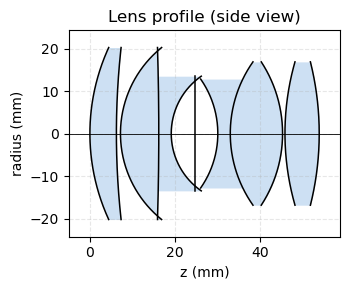

In [109]:
LENS_LENGTH_MM = sum(seg[1] for seg in LENS)


def spherical_profile(curvature, z_surface, aperture, samples=240):
    """Return z(r), r arrays for a spherical surface located at z_surface."""
    if aperture <= 0.0:
        return None
    r = np.linspace(-aperture, aperture, samples)
    if abs(curvature) < 1e-9:
        z = np.full_like(r, z_surface, dtype=float)
    else:
        radius = abs(curvature)
        z_center = z_surface + curvature
        sag = np.sqrt(np.clip(radius * radius - r * r, 0.0, None))
        z = z_center - np.sign(curvature) * sag
    return z, r


def add_lens_profile(ax, lens=LENS, *, samples=240, glass_color="#71a7dd", glass_alpha=0.35):
    surfaces = []
    z_surface = 0.0
    for curvature, thickness, n_next, aperture in lens:
        profile = spherical_profile(curvature, z_surface, aperture, samples=samples)
        surfaces.append((curvature, z_surface, aperture, n_next))
        if profile is not None:
            z_vals, r_vals = profile
            ax.plot(z_vals, r_vals, color="black", linewidth=1.1)
        z_surface += thickness

    for idx in range(len(surfaces) - 1):
        curvature_a, z_a, aperture_a, n_medium = surfaces[idx]
        curvature_b, z_b, aperture_b, _ = surfaces[idx + 1]
        if n_medium <= N_AIR + 1e-6:
            continue
        aperture_fill = min(aperture_a, aperture_b)
        if aperture_fill <= 0.0:
            continue
        profile_a = spherical_profile(curvature_a, z_a, aperture_fill, samples=samples)
        profile_b = spherical_profile(curvature_b, z_b, aperture_fill, samples=samples)
        if profile_a is None or profile_b is None:
            continue
        z_left, r_vals = profile_a
        z_right, _ = profile_b
        z_min = np.minimum(z_left, z_right)
        z_max = np.maximum(z_left, z_right)
        ax.fill_betweenx(r_vals, z_min, z_max, color=glass_color, alpha=glass_alpha, linewidth=0.0)
    return surfaces


# Example usage: create a figure, call the helper, and format the plot outside the function.
fig, ax = plt.subplots(figsize=(8.0, 3.0))
add_lens_profile(ax)
ax.axhline(0.0, color="black", linewidth=0.6)
ax.set_title("Lens profile (side view)")
ax.set_xlabel("z (mm)")
ax.set_ylabel("radius (mm)")
ax.set_xlim(-5.0, LENS_LENGTH_MM + 5.0)
ax.set_ylim(-APERTURE_RADIUS * 1.8, APERTURE_RADIUS * 1.8)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate focal distance to focal length conversion

In [110]:
def focus_from_two_rays(object_distance_mm, entry_scale=0.8, record_paths=False):
    origin = np.array([0.0, 0.0, -object_distance_mm], dtype=float)
    entry = entry_scale * APERTURE_RADIUS
    aims = (np.array([0.0, 0.0, 0.0]), np.array([entry, 0.0, 0.0]))
    rays = [trace_ray(origin, aim, record_paths) for aim in aims]
    if any(ray is None for ray in rays):
        return None
    p1, d1 = rays[0]["position"], rays[0]["direction"]
    p2, d2 = rays[1]["position"], rays[1]["direction"]
    a = np.dot(d1, d1)
    b = np.dot(d1, d2)
    c = np.dot(d2, d2)
    w0 = p1 - p2
    d = np.dot(d1, w0)
    e = np.dot(d2, w0)
    denom = a * c - b * b
    if abs(denom) < 1e-12:
        return None
    t1 = (b * e - c * d) / denom
    t2 = (a * e - b * d) / denom
    q1 = p1 + t1 * d1
    q2 = p2 + t2 * d2
    focus_point = 0.5 * (q1 + q2)
    result = {
        "point": focus_point,
        "residual_mm": np.linalg.norm(q1 - q2),
    }
    if record_paths:
        result["paths"] = [r["path"] for r in rays]
    return result

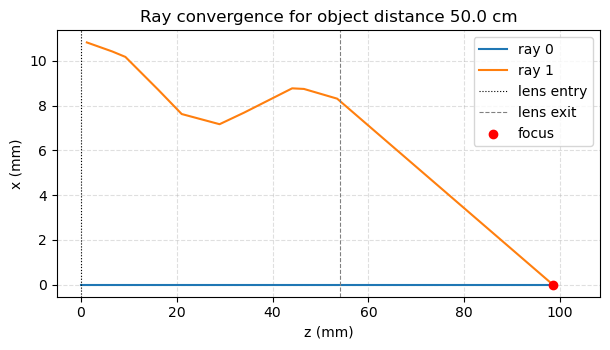

Object distance: 50.000 cm
Distance beyond lens exit: 44.504 mm
Ray intersection residual: 0.000 µm


In [111]:
object_distance_cm = 50.0
focus_info = focus_from_two_rays(object_distance_cm * 10.0, record_paths=True)

if focus_info is None:
    print("Ray tracing failed for the selected object distance.")
else:
    focus = focus_info["point"]
    residual_um = focus_info["residual_mm"] * 1e3

    plt.figure(figsize=(6.2, 3.6))
    for idx, path in enumerate(focus_info.get("paths", [])):
        segment = path[path[:, 2] >= -5.0]
        curve = np.vstack([segment, focus])
        plt.plot(curve[:, 2], curve[:, 0], label=f"ray {idx}")
    plt.axvline(0.0, color="black", linewidth=0.8, linestyle=":", label="lens entry")
    plt.axvline(LENS_LENGTH_MM, color="gray", linewidth=0.8, linestyle="--", label="lens exit")
    plt.scatter([focus[2]], [focus[0]], color="red", zorder=5, label="focus")
    plt.xlabel("z (mm)")
    plt.ylabel("x (mm)")
    plt.title(f"Ray convergence for object distance {object_distance_cm:.1f} cm")
    plt.xlim(-5.0, focus[2] * 1.1)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Object distance: {object_distance_cm:.3f} cm")
    print(f"Distance beyond lens exit: {focus[2] - LENS_LENGTH_MM:.3f} mm")
    print(f"Ray intersection residual: {residual_um:.3f} µm")

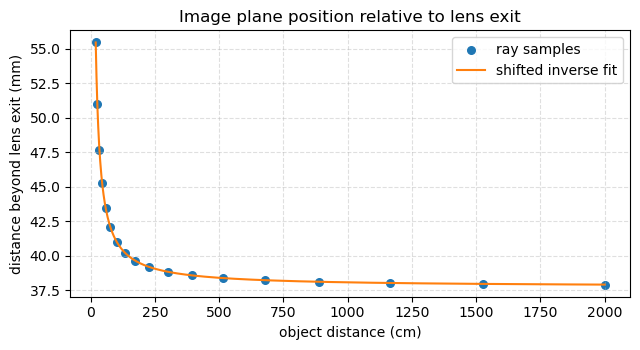

Rational function fit: f(x_cm) = a / (x_cm + b) + c
  a ≈ 326.903 mm·cm
  b ≈ -1.540 cm
  c ≈ 37.758 mm
  MSE ≈ 0.0000 mm^2


In [112]:
from scipy.optimize import curve_fit

object_distances_cm = np.geomspace(20.0, 2000.0, 18)
samples = []
for dist_cm in object_distances_cm:
    focus = focus_from_two_rays(dist_cm * 10.0)
    if focus is None or focus["residual_mm"] > 1e-3:
        continue
    samples.append((dist_cm, focus["point"][2] - LENS_LENGTH_MM))

if not samples:
    print("No focus samples collected.")
else:
    obj_cm, offset_mm = np.array(samples).T
    order = np.argsort(obj_cm)
    obj_cm = obj_cm[order]
    offset_mm = offset_mm[order]

    def rational_function_mm(x_cm, a, b, c):
        return a / (x_cm + b) + c

    popt, _ = curve_fit(rational_function_mm, obj_cm, offset_mm, p0=(5000.0, 0.0, 40.0), maxfev=20000)
    obj_fit = np.geomspace(obj_cm.min(), obj_cm.max(), 200)
    offset_fit = rational_function_mm(obj_fit, *popt)

    plt.figure(figsize=(6.5, 3.6))
    plt.scatter(obj_cm, offset_mm, s=30, label="ray samples")
    plt.plot(obj_fit, offset_fit, color="tab:orange", label="shifted inverse fit")
    plt.xlabel("object distance (cm)")
    plt.ylabel("distance beyond lens exit (mm)")
    plt.title("Image plane position relative to lens exit")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    mse = float(np.mean((rational_function_mm(obj_cm, *popt) - offset_mm) ** 2))
    a_fit, b_fit, c_fit = popt
    print("Rational function fit: f(x_cm) = a / (x_cm + b) + c")
    print(f"  a ≈ {a_fit:.3f} mm·cm")
    print(f"  b ≈ {b_fit:.3f} cm")
    print(f"  c ≈ {c_fit:.3f} mm")
    print(f"  MSE ≈ {mse:.4f} mm^2")

In [113]:
def object_distance_cm_to_focal_length_mm(object_distance_cm):
    a, b, c = popt
    image_distance_mm = rational_function_mm(object_distance_cm, a, b, c) + LENS_LENGTH_MM
    return 1.0 / (1.0 / (object_distance_cm * 10.0) + 1.0 / image_distance_mm)

# Distort noise through the camera lens

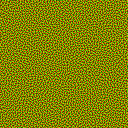

In [114]:
from PIL import Image
path = "C:\\Users\\ckobalt\\Documents\\MasterThesis\\Spatially-Varying-Bokeh\\bokehConfig\\5_fast_noise\\bokeh_fl45.0_as6_samples500000_od500_lidx0of8_0.png"

noisemap = Image.open(path)
display(noisemap)

### Plot noisemap samples

In [115]:
object_distance_cm = 10.0
focal_length_mm = object_distance_cm_to_focal_length_mm(object_distance_cm)

sample_count = 500

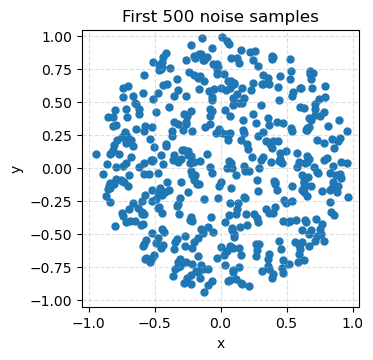

array([[ 0.32549024,  0.082353  ],
       [-0.56078434, -0.6784314 ],
       [-0.08235294,  0.45098042],
       [-0.6627451 ,  0.54509807],
       [-0.6       , -0.42745095],
       [ 0.6       ,  0.4666667 ],
       [-0.94509804,  0.10588241],
       [-0.06666666,  0.5137255 ],
       [ 0.6784314 ,  0.73333335],
       [-0.2235294 ,  0.09019613],
       [ 0.02745104, -0.654902  ],
       [-0.38823527,  0.4666667 ],
       [-0.7490196 , -0.09803921],
       [ 0.13725495, -0.60784316],
       [-0.5294118 ,  0.05882359],
       [-0.12156862, -0.9372549 ],
       [-0.3098039 , -0.2235294 ],
       [-0.14509803,  0.8666667 ],
       [-0.0745098 , -0.372549  ],
       [ 0.73333335, -0.5137255 ],
       [ 0.84313726,  0.22352946],
       [ 0.49803925, -0.26274508],
       [-0.40392154,  0.6392157 ],
       [ 0.827451  , -0.25490195],
       [-0.58431375, -0.5921569 ],
       [ 0.3803922 ,  0.04313731],
       [-0.52156866, -0.16862744],
       [ 0.6627451 , -0.06666666],
       [-0.26274508,

In [116]:
import numpy as np

# Map RGB channels from [0, 255] into [-1, 1] to interpret pixels as 2D positions.
pixel_data = np.asarray(noisemap, dtype=np.float32) / 255.0
flat_pixels = pixel_data.reshape(-1, pixel_data.shape[-1])
if flat_pixels.shape[1] < 2:
    raise ValueError("Noisemap must expose at least two channels for XY data.")
count = min(sample_count, flat_pixels.shape[0])
samples_xy = flat_pixels[:count, :2] * 2.0 - 1.0

fig, ax = plt.subplots(figsize=(3.6, 3.6))
ax.scatter(samples_xy[:, 0], samples_xy[:, 1], color="tab:blue", s=25)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"First {count} noise samples")
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle="--", alpha=0.4)
plt.show()

samples_xy

### Create grid samples

In [117]:
grid_resolution = 50  # number of samples per axis
lin = np.linspace(-1.0, 1.0, grid_resolution, dtype=float)
grid_x, grid_y = np.meshgrid(lin, lin, indexing="xy")
samples_xy = np.column_stack([grid_x.ravel(), grid_y.ravel()])
print(f"samples_xy grid shape: {samples_xy.shape}")

samples_xy grid shape: (2500, 2)


## Make interactible failure and distortion visualization

In [ ]:
from collections import defaultdict

FAILURE_REASON_MARKERS = {
    "aperture_clip": "s",
    "surface_miss": "o",
    "total_internal_reflection": "^",
    "parallel_to_focus_plane": "D",
    "focus_plane_behind": "v",
    "degenerate_direction": "P",
    "unknown": "x",
}

FAILURE_REASON_LABELS = {
    "aperture_clip": "blocked by aperture",
    "surface_miss": "missed surface",
    "total_internal_reflection": "total internal reflection",
    "parallel_to_focus_plane": "parallel to focus plane",
    "focus_plane_behind": "focus plane behind",
    "degenerate_direction": "degenerate direction",
    "unknown": "unknown",
}

success_offsets = np.empty((0, 2), dtype=float)
success_is_center = np.zeros(0, dtype=bool)
landing_xy_mm = np.empty((0, 2), dtype=float)
landing_is_center = np.zeros(0, dtype=bool)
failed_offsets = np.empty((0, 2), dtype=float)
failed_is_center = np.zeros(0, dtype=bool)
failed_element_indices = np.zeros(0, dtype=int)
failed_reasons = np.empty(0, dtype=object)
landing_failed_xy = np.empty((0, 2), dtype=float)
landing_failed_is_center = np.zeros(0, dtype=bool)
failures_by_element = {}
world_origin = np.zeros(3, dtype=float)
focus_plane_z_current = 100.0
object_distance_current_cm = None
angle_x_current_deg = 0.0
angle_y_current_deg = 0.0

ELEMENT_ORDER = [-1] + list(range(len(LENS))) + [len(LENS)]
ELEMENT_LABELS = {idx: f"Element {idx + 1}" for idx in range(len(LENS))}
ELEMENT_LABELS[-1] = "Before lens"
ELEMENT_LABELS[len(LENS)] = "After lens"
ELEMENT_OPTIONS = [("Show all", "all")] + [(ELEMENT_LABELS[idx], idx) for idx in ELEMENT_ORDER]

element_cmap = plt.cm.get_cmap("tab20", max(len(LENS), 1))
ELEMENT_COLORS = {
    -1: (0.45, 0.45, 0.45, 1.0),
    len(LENS): (0.1, 0.55, 0.5, 1.0),
}
for idx in range(len(LENS)):
    ELEMENT_COLORS[idx] = element_cmap(idx % element_cmap.N)
del element_cmap

def make_empty_failure_group():
    return {
        "offsets": np.empty((0, 2), dtype=float),
        "is_center": np.zeros(0, dtype=bool),
        "reasons": np.empty(0, dtype=object),
        "landings": np.empty((0, 2), dtype=float),
    }

def element_label(idx):
    return ELEMENT_LABELS.get(idx, f"Element {idx}")

def element_color(idx):
    return ELEMENT_COLORS.get(idx, (0.85, 0.2, 0.2, 1.0))

def collect_ray_bundle(object_distance_cm, angle_x_deg, angle_y_deg, focus_plane_z):
    object_distance_mm = float(object_distance_cm) * 10.0
    angle_x_rad = np.deg2rad(angle_x_deg)
    angle_y_rad = np.deg2rad(angle_y_deg)
    world_origin_local = np.array([
        object_distance_mm * np.tan(angle_x_rad),
        object_distance_mm * np.tan(angle_y_rad),
        -object_distance_mm,
    ], dtype=float)
    entry_offsets = np.vstack([samples_xy, np.zeros((1, 2), dtype=samples_xy.dtype)])
    is_center = np.zeros(entry_offsets.shape[0], dtype=bool)
    is_center[-1] = True
    opening_radius = radii[1]
    entry_points_mm = np.column_stack([
        entry_offsets * opening_radius,
        np.zeros(entry_offsets.shape[0]),
    ])

    success_offsets_acc = []
    success_is_center_acc = []
    landing_success_acc = []
    failure_primary_acc = []
    landing_fail_acc = []
    landing_fail_center_acc = []
    failure_map = defaultdict(list)

    for offset_rel, entry_point, center_flag in zip(entry_offsets, entry_points_mm, is_center):
        info = trace_ray_permissible(
            world_origin_local,
            entry_point,
            focus_plane_z=focus_plane_z,
            record_path=False,
        )
        landing_xy = info["landing"][:2]
        failures = info.get("failures", [])
        if not failures:
            success_offsets_acc.append(offset_rel)
            success_is_center_acc.append(center_flag)
            landing_success_acc.append(landing_xy)
        else:
            primary = failures[0]
            idx_primary = primary.get("index", -1)
            reason_primary = primary.get("reason", "unknown")
            failure_primary_acc.append((offset_rel, center_flag, idx_primary, reason_primary))
            landing_fail_acc.append(landing_xy)
            landing_fail_center_acc.append(center_flag)
        for failure in failures:
            failure_idx = failure.get("index", -1)
            failure_reason = failure.get("reason", "unknown")
            failure_map[failure_idx].append((offset_rel, center_flag, failure_reason, landing_xy))

    success_offsets_arr = np.asarray(success_offsets_acc, dtype=float) if success_offsets_acc else np.empty((0, 2), dtype=float)
    success_is_center_arr = np.asarray(success_is_center_acc, dtype=bool) if success_is_center_acc else np.zeros(0, dtype=bool)
    landing_success_arr = np.asarray(landing_success_acc, dtype=float) if landing_success_acc else np.empty((0, 2), dtype=float)

    if failure_primary_acc:
        failed_offsets_arr = np.asarray([rec[0] for rec in failure_primary_acc], dtype=float)
        failed_is_center_arr = np.asarray([rec[1] for rec in failure_primary_acc], dtype=bool)
        failed_indices_arr = np.asarray([rec[2] for rec in failure_primary_acc], dtype=int)
        failed_reasons_arr = np.asarray([rec[3] for rec in failure_primary_acc], dtype=object)
    else:
        failed_offsets_arr = np.empty((0, 2), dtype=float)
        failed_is_center_arr = np.zeros(0, dtype=bool)
        failed_indices_arr = np.zeros(0, dtype=int)
        failed_reasons_arr = np.empty(0, dtype=object)

    landing_fail_arr = np.asarray(landing_fail_acc, dtype=float) if landing_fail_acc else np.empty((0, 2), dtype=float)
    landing_fail_center_arr = np.asarray(landing_fail_center_acc, dtype=bool) if landing_fail_center_acc else np.zeros(0, dtype=bool)

    failure_summary = {}
    for idx, items in failure_map.items():
        if not items:
            continue
        failure_summary[idx] = {
            "offsets": np.asarray([item[0] for item in items], dtype=float),
            "is_center": np.asarray([item[1] for item in items], dtype=bool),
            "reasons": np.asarray([item[2] for item in items], dtype=object),
            "landings": np.asarray([item[3] for item in items], dtype=float),
        }

    return {
        "world_origin": world_origin_local,
        "success_offsets": success_offsets_arr,
        "success_is_center": success_is_center_arr,
        "landing_xy_mm": landing_success_arr,
        "landing_is_center": success_is_center_arr.copy(),
        "failed_offsets": failed_offsets_arr,
        "failed_is_center": failed_is_center_arr,
        "failed_element_indices": failed_indices_arr,
        "failed_reasons": failed_reasons_arr,
        "landing_failed_xy": landing_fail_arr,
        "landing_failed_is_center": landing_fail_center_arr,
        "failures_by_element": failure_summary,
    }

def plot_aperture_response(
    object_distance_cm,
    angle_x_deg=0.0,
    angle_y_deg=0.0,
    focus_plane_z=100.0,
    highlight_element="all",
):
    global success_offsets, success_is_center, landing_xy_mm, landing_is_center
    global failed_offsets, failed_is_center, failed_element_indices, failed_reasons
    global landing_failed_xy, landing_failed_is_center, failures_by_element
    global world_origin, focus_plane_z_current, object_distance_current_cm
    global angle_x_current_deg, angle_y_current_deg

    bundle = collect_ray_bundle(object_distance_cm, angle_x_deg, angle_y_deg, focus_plane_z)

    success_offsets = bundle["success_offsets"]
    success_is_center = bundle["success_is_center"]
    landing_xy_mm = bundle["landing_xy_mm"]
    landing_is_center = bundle["landing_is_center"]
    failed_offsets = bundle["failed_offsets"]
    failed_is_center = bundle["failed_is_center"]
    failed_element_indices = bundle["failed_element_indices"]
    failed_reasons = bundle["failed_reasons"]
    landing_failed_xy = bundle["landing_failed_xy"]
    landing_failed_is_center = bundle["landing_failed_is_center"]

    failures_filled = {idx: make_empty_failure_group() for idx in ELEMENT_ORDER}
    for idx, group in bundle["failures_by_element"].items():
        failures_filled[idx] = group
    failures_by_element = failures_filled

    world_origin = bundle["world_origin"]
    focus_plane_z_current = float(focus_plane_z)
    object_distance_current_cm = float(object_distance_cm)
    angle_x_current_deg = float(angle_x_deg)
    angle_y_current_deg = float(angle_y_deg)

    highlight_idx_int = None
    highlight_group = make_empty_failure_group()
    highlight_label = ""
    highlight_color = (0.8, 0.2, 0.2, 0.9)
    if highlight_element != "all":
        highlight_idx_int = int(highlight_element)
        highlight_group = failures_by_element.get(highlight_idx_int, make_empty_failure_group())
        highlight_label = element_label(highlight_idx_int)
        highlight_color = element_color(highlight_idx_int)

    fig, (ax_offsets, ax_landings, ax_summary) = plt.subplots(1, 3, figsize=(12.0, 4.0))

    if success_offsets.size:
        mask = ~landing_is_center
        if np.any(mask):
            ax_offsets.scatter(
                success_offsets[mask, 0],
                success_offsets[mask, 1],
                s=18,
                color="tab:blue",
                label="pass",
            )
        if landing_is_center.any():
            ax_offsets.scatter(0.0, 0.0, s=55, color="tab:orange", label="center pass")

    if failed_offsets.size:
        base_mask = np.ones(failed_offsets.shape[0], dtype=bool)
        if highlight_idx_int is not None:
            base_mask = failed_element_indices != highlight_idx_int
        if np.any(base_mask):
            ax_offsets.scatter(
                failed_offsets[base_mask, 0],
                failed_offsets[base_mask, 1],
                s=20,
                color="#b8b8b8",
                label="fail (other)",
            )

    if highlight_idx_int is not None and highlight_group["offsets"].size:
        reasons = highlight_group["reasons"]
        offsets = highlight_group["offsets"]
        used_labels = set()
        for reason in np.unique(reasons):
            reason_mask = reasons == reason
            marker = FAILURE_REASON_MARKERS.get(reason, "x")
            label = f"{highlight_label}: {FAILURE_REASON_LABELS.get(reason, reason)}"
            if label in used_labels:
                label = None
            else:
                used_labels.add(label)
            ax_offsets.scatter(
                offsets[reason_mask, 0],
                offsets[reason_mask, 1],
                s=55,
                marker=marker,
                color=highlight_color,
                alpha=0.88,
                label=label,
            )

    ax_offsets.set_title("Aperture offsets (normalized)")
    ax_offsets.set_xlabel("x (rel)")
    ax_offsets.set_ylabel("y (rel)")
    ax_offsets.set_xlim(-1.05, 1.05)
    ax_offsets.set_ylim(-1.05, 1.05)
    ax_offsets.set_aspect("equal", adjustable="box")
    ax_offsets.grid(True, linestyle="--", alpha=0.4)
    handles, labels = ax_offsets.get_legend_handles_labels()
    if handles:
        ax_offsets.legend(loc="upper right", fontsize=8)

    if landing_xy_mm.size:
        non_center = ~landing_is_center
        if np.any(non_center):
            ax_landings.scatter(
                landing_xy_mm[non_center, 0],
                landing_xy_mm[non_center, 1],
                s=12,
                color="tab:blue",
                label="pass",
            )
        if landing_is_center.any():
            center_point = landing_xy_mm[landing_is_center][0]
            ax_landings.scatter(
                center_point[0],
                center_point[1],
                s=45,
                color="tab:orange",
                label="center pass",
            )
    else:
        ax_landings.text(
            0.5,
            0.5,
            "No rays reached focus plane",
            ha="center",
            va="center",
            transform=ax_landings.transAxes,
        )

    if highlight_idx_int is not None and highlight_group["landings"].size:
        ax_landings.scatter(
            highlight_group["landings"][:, 0],
            highlight_group["landings"][:, 1],
            s=40,
            marker="x",
            color=highlight_color,
            label=f"{highlight_label} (permissible)",
        )

    ax_landings.set_title("Landing points on focus plane")
    ax_landings.set_xlabel("x (mm)")
    ax_landings.set_ylabel("y (mm)")
    ax_landings.set_aspect("equal", adjustable="box")
    ax_landings.grid(True, linestyle="--", alpha=0.4)
    handles, labels = ax_landings.get_legend_handles_labels()
    if handles:
        ax_landings.legend(loc="upper right", fontsize=8)

    ax_summary.axis("off")

    def failure_count(idx):
        group = failures_by_element.get(idx)
        return int(group["offsets"].shape[0]) if group and group["offsets"].size else 0

    summary_lines = [
        f"successful rays: {success_offsets.shape[0]}",
        f"failed rays (primary): {failed_offsets.shape[0]}",
        "",
        f"object distance: {object_distance_current_cm:.2f} cm",
        f"angles: {angle_x_current_deg:.1f}° / {angle_y_current_deg:.1f}°",
        f"focus plane z: {focus_plane_z_current:.1f} mm",
        "",
        "failure counts:",
    ]
    for idx in ELEMENT_ORDER:
        summary_lines.append(f"  {element_label(idx)}: {failure_count(idx)}")

    if highlight_idx_int is not None:
        summary_lines.append("")
        summary_lines.append(f"{highlight_label} reasons:")
        if highlight_group["reasons"].size:
            unique_reasons, counts = np.unique(highlight_group["reasons"], return_counts=True)
            for reason, count in zip(unique_reasons, counts):
                summary_lines.append(
                    f"  {FAILURE_REASON_LABELS.get(reason, reason)}: {int(count)}"
                )
        else:
            summary_lines.append("  none")

    ax_summary.text(
        0.0,
        1.0,
        "\n".join(summary_lines),
        fontsize=9,
        va="top",
        ha="left",
        transform=ax_summary.transAxes,
    )

    plt.tight_layout()
    plt.show()

object_distance_widget = widgets.FloatLogSlider(
    value=10.0,
    base=10,
    min=np.log10(5.0),
    max=np.log10(500.0),
    step=0.01,
    description="Object dist (cm)",
    continuous_update=True,
)
angle_x_widget = widgets.FloatSlider(
    value=0.0,
    min=-20.0,
    max=20.0,
    step=0.1,
    description="Angle X (°)",
    continuous_update=True,
)
angle_y_widget = widgets.FloatSlider(
    value=0.0,
    min=-20.0,
    max=20.0,
    step=0.1,
    description="Angle Y (°)",
    continuous_update=True,
)
highlight_element_widget = widgets.Dropdown(
    options=ELEMENT_OPTIONS,
    value="all",
    description="Highlight",
)

widgets.interact(
    plot_aperture_response,
    object_distance_cm=object_distance_widget,
    angle_x_deg=angle_x_widget,
    angle_y_deg=angle_y_widget,
    highlight_element=highlight_element_widget,
)

C:\Users\ckobalt\AppData\Local\Temp\1\ipykernel_35284\58734268.py:46: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  element_cmap = plt.cm.get_cmap("tab20", max(len(LENS), 1))


interactive(children=(FloatLogSlider(value=10.0, description='Object dist (cm)', max=2.6989700043360187, min=0…

<function __main__.plot_aperture_response(object_distance_cm, angle_x_deg=0.0, angle_y_deg=0.0, focus_plane_z=100.0, highlight_element='all')>

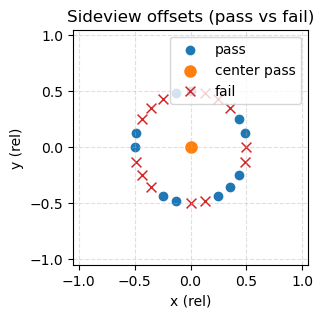

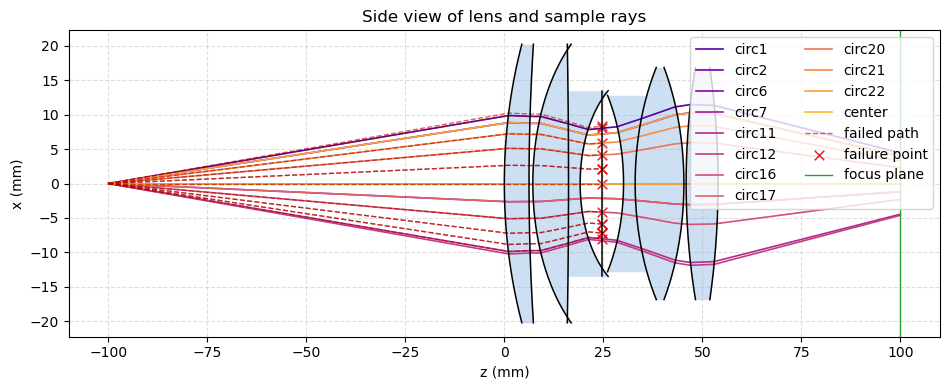

In [119]:
circle_count = 24
angles = np.linspace(0.0, 2.0 * np.pi, circle_count, endpoint=False)
sideview_offsets = np.vstack([np.column_stack([np.cos(angles), np.sin(angles)]), np.zeros((1, 2))]) * 0.5
sideview_labels = [f"circ{i}" for i in range(circle_count)] + ["center"]

# Trace each sample ray to determine pass/fail status.
sideview_success_paths = []
sideview_success_labels = []
sideview_success_samples = []
sideview_failure_paths = []
sideview_failure_points = []
sideview_failure_samples = []

for offset, label in zip(sideview_offsets, sideview_labels):
    opening_radii = radii[1]
    entry_point_mm = np.array([offset[0] * opening_radii, offset[1] * opening_radii, 0.0])
    ray_info = trace_ray_verbose(world_origin, entry_point_mm)
    result = ray_info["result"]
    path = ray_info["path"]

    if result is None:
        sideview_failure_paths.append(path)
        sideview_failure_points.append(ray_info["failure_point"])
        sideview_failure_samples.append((offset, label))
        continue

    last_pos = result["position"]
    last_dir = result["direction"]
    if abs(last_dir[2]) < 1e-9:
        sideview_failure_paths.append(path)
        sideview_failure_points.append(path[-1])
        sideview_failure_samples.append((offset, label))
        continue

    travel = (focus_plane_z_current - last_pos[2]) / last_dir[2]
    if travel <= 0.0:
        sideview_failure_paths.append(path)
        sideview_failure_points.append(path[-1])
        sideview_failure_samples.append((offset, label))
        continue

    landing_point = last_pos + travel * last_dir
    sideview_success_paths.append(np.vstack([path, landing_point]))
    sideview_success_labels.append(label)
    sideview_success_samples.append((offset, label))

fig, ax = plt.subplots(figsize=(3.4, 3.4))
if sideview_success_samples:
    success_offsets = np.asarray([sample[0] for sample in sideview_success_samples], dtype=float)
    success_labels = [sample[1] for sample in sideview_success_samples]
    success_center_mask = np.array([label == "center" for label in success_labels], dtype=bool)
    if np.any(~success_center_mask):
        ax.scatter(
            success_offsets[~success_center_mask, 0],
            success_offsets[~success_center_mask, 1],
            s=36,
            color="tab:blue",
            label="pass",
)
    if np.any(success_center_mask):
        ax.scatter(
            success_offsets[success_center_mask, 0],
            success_offsets[success_center_mask, 1],
            s=64,
            color="tab:orange",
            label="center pass",
)
if sideview_failure_samples:
    failure_offsets = np.asarray([sample[0] for sample in sideview_failure_samples], dtype=float)
    failure_labels = [sample[1] for sample in sideview_failure_samples]
    failure_center_mask = np.array([label == "center" for label in failure_labels], dtype=bool)
    if np.any(~failure_center_mask):
        ax.scatter(
            failure_offsets[~failure_center_mask, 0],
            failure_offsets[~failure_center_mask, 1],
            s=50,
            color="tab:red",
            marker="x",
            linewidths=1.1,
            label="fail",
)
    if np.any(failure_center_mask):
        ax.scatter(
            failure_offsets[failure_center_mask, 0],
            failure_offsets[failure_center_mask, 1],
            s=70,
            color="tab:red",
            marker="X",
            linewidths=1.2,
            label="center fail",
)
if not sideview_success_samples and not sideview_failure_samples:
    ax.scatter(sideview_offsets[:-1, 0], sideview_offsets[:-1, 1], s=36, color="tab:purple", label="ring samples")
    ax.scatter(0.0, 0.0, s=64, color="tab:orange", label="center")
ax.set_title("Sideview offsets (pass vs fail)")
ax.set_xlabel("x (rel)")
ax.set_ylabel("y (rel)")
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.4)
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

if sideview_success_paths or sideview_failure_paths:
    fig, ax = plt.subplots(figsize=(9.6, 4.0))

    # Plot successful ray paths
    if sideview_success_paths:
        colors = plt.cm.plasma(np.linspace(0.15, 0.85, len(sideview_success_paths)))
        for path, label, color in zip(sideview_success_paths, sideview_success_labels, colors):
            ax.plot(path[:, 2], path[:, 0], color=color, linewidth=1.2, label=label)

    # Plot failed ray paths and failure points
    failed_path_color = (0.7, 0.0, 0.0, 0.6)
    failed_point_color = (0.9, 0.0, 0.0, 0.85)
    for idx, (path, point) in enumerate(zip(sideview_failure_paths, sideview_failure_points)):
        label_line = "failed path" if idx == 0 else None
        label_point = "failure point" if idx == 0 else None
        if path is not None and path.size:
            ax.plot(path[:, 2], path[:, 0], color=failed_path_color, linewidth=1.0, linestyle="--", label=label_line)
        if point is not None:
            ax.scatter(point[2], point[0], color=failed_point_color, s=48, marker="x", linewidths=1.1, label=label_point)

    # Plot lens profile
    add_lens_profile(ax)

    ax.axvline(focus_plane_z_current, color="tab:green", linewidth=1, label="focus plane")
    ax.set_title("Side view of lens and sample rays")
    ax.set_xlabel("z (mm)")
    ax.set_ylabel("x (mm)")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(loc="upper right", ncol=2)
    plt.tight_layout()
    plt.show()

C:\Users\ckobalt\AppData\Local\anaconda3\Lib\site-packages\skimage\measure\fit.py:308: UserWarning: Input does not contain enough significant data points.
  warn("Input does not contain enough significant data points.")


Ring projection summary (mm):
angleX=-40.0°, element= 1, center=( -3.645,   0.018), radius= 19.843± 0.017, samples= 209
angleX=-40.0°, element= 2, center=( -4.666,   0.001), radius= 20.818± 0.015, samples= 215
angleX=-40.0°, element= 3, center=(-12.675,   0.006), radius= 23.054± 0.016, samples=  88
angleX=-40.0°, element= 5, center=(-12.478,  -0.095), radius= 19.259± 0.015, samples=  83
angleX=-40.0°, element= 6, center=(-37.950,   0.004), radius= 18.379± 0.015, samples=  63
angleX=-40.0°, element= 7, center=(-38.712,   0.203), radius= 14.893± 0.015, samples=  46
angleX=-20.0°, element= 1, center=( -1.538,  -0.115), radius= 20.116± 0.017, samples= 207
angleX=-20.0°, element= 2, center=( -2.340,   0.098), radius= 20.538± 0.017, samples= 242
angleX=-20.0°, element= 3, center=( -5.773,   0.107), radius= 22.557± 0.017, samples= 230
angleX=-20.0°, element= 5, center=( -7.931,  -0.010), radius= 20.994± 0.018, samples= 192
angleX=-20.0°, element= 7, center=(-10.227,  -0.101), radius= 19.248± 

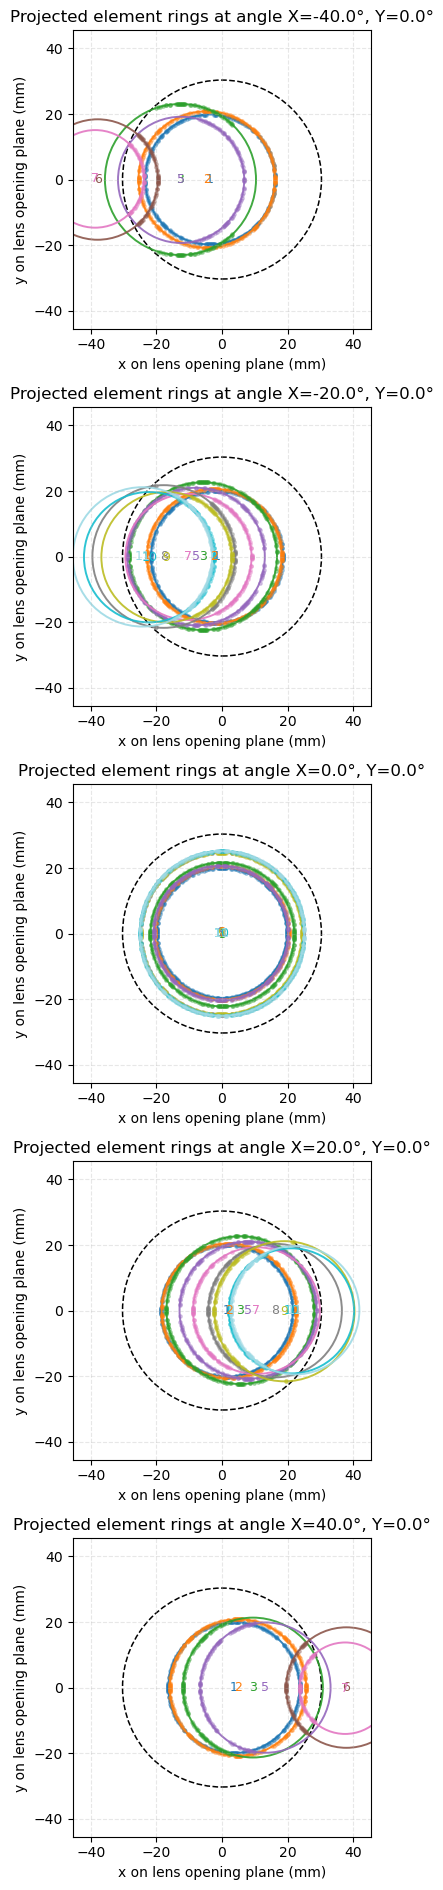

In [129]:
RING_ANALYSIS_DISTANCE_MM = 400.0
RING_ANALYSIS_ANGLES_X_DEG = np.linspace(-40.0, 40.0, 5)
RING_ANALYSIS_ANGLES_Y_DEG = np.array([0.0])
RING_SAMPLE_GRID = 300
RING_ENTRY_MARGIN = 1.5
RING_HIT_BAND_FRACTION = 0.02
RING_MIN_BAND_MM = 0.01
RING_RANSAC_RESIDUAL_MM = 0.03
RING_RANSAC_MAX_TRIALS = 800
RING_REPORT_ELEMENTS = sorted(set(range(len(LENS))).union(TEXTURED_APERTURE_INDICES))

def world_origin_from_angles(distance_mm, angle_x_deg, angle_y_deg):
    angle_x_rad = np.deg2rad(angle_x_deg)
    angle_y_rad = np.deg2rad(angle_y_deg)
    return np.array([
        distance_mm * np.tan(angle_x_rad),
        distance_mm * np.tan(angle_y_rad),
        -distance_mm,
    ], dtype=float)

def generate_entry_samples(grid_resolution, radius_mm, margin=1.0):
    lin = np.linspace(-margin, margin, grid_resolution, dtype=float)
    grid_x, grid_y = np.meshgrid(lin, lin, indexing="xy")
    offsets = np.column_stack([grid_x.ravel(), grid_y.ravel()]) * radius_mm
    mask = np.linalg.norm(offsets, axis=1) <= margin * radius_mm
    offsets = offsets[mask]
    points = np.column_stack([offsets, np.zeros(offsets.shape[0], dtype=float)])
    return offsets, points

def trace_ray_with_hits(world_origin, entry_point):
    origin = np.asarray(world_origin, dtype=float)
    direction = np.asarray(entry_point, dtype=float) - origin
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        return {
            "hits": [],
            "terminal_reason": "degenerate_direction"
        }
    direction /= norm_dir
    hits = []
    current = origin.copy()
    z_surface = 0.0
    n_current = N_AIR
    for elem_index, (curvature, thickness, n_next, aperture) in enumerate(LENS):
        record = {
            "element_index": elem_index,
            "aperture_radius": aperture,
            "z_surface": z_surface
        }
        result = intersect_surface(current, direction, curvature, z_surface)
        if result is None:
            record.update({
                "status": "surface_miss",
                "hit": False,
                "point": current.copy()
            })
            hits.append(record)
            next_z = z_surface + thickness
            dz = direction[2]
            if abs(dz) < 1e-9:
                current = np.array([current[0], current[1], next_z])
            else:
                t = (next_z - current[2]) / dz
                current = current + direction * t
            z_surface += thickness
            n_current = n_next
            continue
        hit_point, normal = result
        radius_at_hit = np.linalg.norm(hit_point[:2])
        clipped = aperture > 0.0 and radius_at_hit > aperture
        record.update({
            "status": "hit_clipped" if clipped else "hit",
            "hit": True,
            "point": hit_point,
            "radius_at_hit": radius_at_hit,
            "clipped": clipped
        })
        eta = n_current / n_next
        refracted = refract(direction, normal, eta)
        if refracted is None:
            record["status"] = "total_internal_reflection"
            record["passes"] = False
            hits.append(record)
            break
        record["passes"] = True
        hits.append(record)
        direction = refracted / np.linalg.norm(refracted)
        current = hit_point
        n_current = n_next
        z_surface += thickness
    return {
        "hits": hits,
        "terminal_reason": hits[-1]["status"] if hits else "completed"
    }

def collect_ring_projections(distance_mm, angle_pairs, grid_resolution, margin, band_fraction, min_band_mm):
    front_radius = LENS[0][3]
    entry_offsets_mm, entry_points_mm = generate_entry_samples(grid_resolution, front_radius, margin)
    projections = []
    for angle_x_deg, angle_y_deg in angle_pairs:
        world_origin = world_origin_from_angles(distance_mm, angle_x_deg, angle_y_deg)
        ring_hits = {idx: [] for idx in range(len(LENS))}
        for offset_mm, entry_point_mm in zip(entry_offsets_mm, entry_points_mm):
            trace = trace_ray_with_hits(world_origin, entry_point_mm)
            for hit in trace["hits"]:
                aperture = hit.get("aperture_radius", 0.0)
                if aperture <= 0.0 or not hit.get("hit", False):
                    continue
                radius_at_hit = hit.get("radius_at_hit", np.inf)
                band_mm = max(band_fraction * aperture, min_band_mm)
                if abs(radius_at_hit - aperture) <= band_mm:
                    ring_hits[hit["element_index"]].append(offset_mm)
        projections.append({
            "angle_x_deg": angle_x_deg,
            "angle_y_deg": angle_y_deg,
            "world_origin": world_origin,
            "entry_offsets_mm": entry_offsets_mm,
            "ring_hits": ring_hits
        })
    return projections

def fit_circle_model(points_mm):
    points = np.asarray(points_mm, dtype=float)
    if points.shape[0] < 3:
        return None
    residual_threshold = max(RING_RANSAC_RESIDUAL_MM, 0.5 * RING_MIN_BAND_MM)
    try:
        model, inliers = measure.ransac(
            points,
            measure.CircleModel,
            min_samples=3,
            residual_threshold=residual_threshold,
            max_trials=RING_RANSAC_MAX_TRIALS,
        )
    except ValueError:
        model, inliers = (None, None)
    if model is None or inliers is None or not np.any(inliers):
        model_direct = measure.CircleModel()
        if not model_direct.estimate(points):
            return None
        model = model_direct
        inliers = np.ones(points.shape[0], dtype=bool)
    xc, yc, radius = model.params
    if not np.isfinite(radius) or radius <= 0.0:
        return None
    center = np.array([xc, yc], dtype=float)
    inlier_points = points[inliers]
    radii = np.linalg.norm(inlier_points - center, axis=1)
    radius_std = radii.std(ddof=1) if radii.size > 1 else 0.0
    residuals = radii - radius
    return {
        "center_mm": center,
        "radius_mm": float(radius),
        "radius_std_mm": float(radius_std),
        "sample_count": int(inlier_points.shape[0]),
        "offsets_mm": inlier_points,
        "residuals_mm": residuals
    }

def summarize_ring_hits(ring_hits):
    summary = {}
    for elem_index, offsets in ring_hits.items():
        if not offsets:
            summary[elem_index] = None
            continue
        fit = fit_circle_model(offsets)
        summary[elem_index] = fit
    return summary

angle_pairs = [(float(ax), float(ay)) for ax in RING_ANALYSIS_ANGLES_X_DEG for ay in RING_ANALYSIS_ANGLES_Y_DEG]
ring_projections = collect_ring_projections(
    RING_ANALYSIS_DISTANCE_MM,
    angle_pairs,
    RING_SAMPLE_GRID,
    RING_ENTRY_MARGIN,
    RING_HIT_BAND_FRACTION,
    RING_MIN_BAND_MM,
 )
ring_summaries = [
    {
        "angle_x_deg": proj["angle_x_deg"],
        "angle_y_deg": proj["angle_y_deg"],
        "summaries": summarize_ring_hits(proj["ring_hits"])
    }
    for proj in ring_projections
 ]

fig, axes = plt.subplots(len(ring_summaries), 1, figsize=(6.5, 3.8 * len(ring_summaries)))
if len(ring_summaries) == 1:
    axes = [axes]

entry_radius = LENS[0][3] * RING_ENTRY_MARGIN
for ax, proj, summary in zip(axes, ring_projections, ring_summaries):
    ax.set_title(
        f"Projected element rings at angle X={proj['angle_x_deg']:.1f}°, Y={proj['angle_y_deg']:.1f}°"
    )
    ax.set_xlabel("x on lens opening plane (mm)")
    ax.set_ylabel("y on lens opening plane (mm)")
    ax.set_aspect("equal", adjustable="box")
    entry_circle = plt.Circle((0.0, 0.0), entry_radius, edgecolor="black", facecolor="none", linestyle="--", linewidth=1.1)
    ax.add_patch(entry_circle)
    for elem_index in RING_REPORT_ELEMENTS:
        info = summary["summaries"].get(elem_index)
        if info is None:
            continue
        color = ELEMENT_COLORS.get(elem_index, (0.3, 0.3, 0.3, 1.0))
        offsets = info["offsets_mm"]
        if offsets.size:
            ax.scatter(offsets[:, 0], offsets[:, 1], s=6, color=color, alpha=0.35)
        circle = plt.Circle(info["center_mm"], info["radius_mm"], edgecolor=color, facecolor="none", linewidth=1.4, alpha=0.9)
        ax.add_patch(circle)
        ax.text(
            info["center_mm"][0],
            info["center_mm"][1],
            f"{elem_index + 1}",
            color=color,
            fontsize=9,
            ha="center",
            va="center",
        )
    extent = entry_radius * RING_ENTRY_MARGIN
    ax.set_xlim(-extent, extent)
    ax.set_ylim(-extent, extent)
    ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

summary_rows = []
for summary in ring_summaries:
    for elem_index, stats in summary["summaries"].items():
        if stats is None:
            continue
        summary_rows.append({
            "angle_x_deg": summary["angle_x_deg"],
            "angle_y_deg": summary["angle_y_deg"],
            "element_index": elem_index,
            "center_x_mm": stats["center_mm"][0],
            "center_y_mm": stats["center_mm"][1],
            "radius_mm": stats["radius_mm"],
            "radius_std_mm": stats["radius_std_mm"],
            "samples": stats["sample_count"],
        })

if summary_rows:
    print("Ring projection summary (mm):")
    for row in summary_rows:
        print(
            f"angleX={row['angle_x_deg']:5.1f}°, element={row['element_index'] + 1:2d}, "
            f"center=({row['center_x_mm']:7.3f}, {row['center_y_mm']:7.3f}), "
            f"radius={row['radius_mm']:7.3f}±{row['radius_std_mm']:6.3f}, samples={row['samples']:4d}"
        )
else:
    print("No ring hits recorded with the current sampling settings.")